# Phase 3 RNN for Fake News Detection

This notebook implements a reproducible recurrent neural network pipeline for the updated Phase 3 requirements. It loads the cleaned project dataset, prepares tokenized sequences, trains an RNN classifier, and evaluates the model on a held-out test set.

## Goals
- Train a recurrent model for binary fake news detection.
- Keep the workflow reproducible with fixed seeds and deterministic settings where possible.
- Document the data preparation, model design, training, and evaluation steps clearly for assessment.

In [1]:
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, Embedding, SimpleRNN, SpatialDropout1D
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

print('TensorFlow version:', tf.__version__)
print('NumPy version:', np.__version__)

TensorFlow version: 2.21.0
NumPy version: 2.2.6


## Load the prepared dataset

The notebook uses the cleaned dataset generated by the project preprocessing pipeline. If the processed file is not available, the project can be regenerated from the raw CSV before rerunning this notebook.

In [3]:
def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        processed_file = candidate / 'data' / 'processed' / 'processed.csv'
        if processed_file.exists():
            return candidate
    raise FileNotFoundError('Could not locate data/processed/processed.csv from the current working directory.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'processed' / 'processed.csv'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'models'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df['cleaned_text'] = df['cleaned_text'].astype(str)
df['target'] = df['target'].astype(int)

MAX_ROWS = 50000
if len(df) > MAX_ROWS:
    df, _ = train_test_split(
        df,
        train_size=MAX_ROWS,
        random_state=SEED,
        stratify=df['target'],
    )
    df = df.reset_index(drop=True)
    print(f'Using a reproducible stratified sample of {MAX_ROWS:,} rows for the RNN run.')

print('Project root:', PROJECT_ROOT)
print('Dataset shape:', df.shape)
print(df.head())

Using a reproducible stratified sample of 50,000 rows for the RNN run.
Project root: C:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers
Dataset shape: (50000, 2)
                                        cleaned_text  target
0  better taking pictures woman miss tooooo dont ...       0
1                    awww yay baby bunnies sooo cute       1
2                         st fathers day without dad       0
3  ok feed dog watered garden needed collared nex...       1
4  usa wins still shaky though lot weaknesses nee...       1


## Train, validation, and test split

A stratified split keeps the class balance stable across the three partitions. The RNN is trained only on the training split, tuned on validation data, and evaluated once on the test split.

In [4]:
texts = df['cleaned_text'].tolist()
labels = df['target'].to_numpy()

x_train_texts, x_temp_texts, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

x_val_texts, x_test_texts, y_val, y_test = train_test_split(
    x_temp_texts,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
)

MAX_VOCAB_SIZE = 12000
MAX_SEQUENCE_LENGTH = 100
EMBEDDING_DIM = 64

tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(x_train_texts)

x_train_seq = tokenizer.texts_to_sequences(x_train_texts)
x_val_seq = tokenizer.texts_to_sequences(x_val_texts)
x_test_seq = tokenizer.texts_to_sequences(x_test_texts)

x_train_pad = pad_sequences(x_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
x_val_pad = pad_sequences(x_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
x_test_pad = pad_sequences(x_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print('Train / val / test sizes:', len(x_train_pad), len(x_val_pad), len(x_test_pad))
print('Vocabulary size learned:', min(MAX_VOCAB_SIZE, len(tokenizer.word_index) + 1))

Train / val / test sizes: 35000 7500 7500
Vocabulary size learned: 12000


## Build the RNN model

The architecture uses an embedding layer followed by a `SimpleRNN` block. This keeps the model aligned with the Phase 3 RNN requirement while staying compact enough to train quickly for assessment.

In [10]:
model = Sequential([
    Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=EMBEDDING_DIM),
    SpatialDropout1D(0.2),
    SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the RNN

Early stopping is used to reduce overfitting and keep the training run stable. The best validation model is restored automatically.

In [11]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
]

history = model.fit(
    x_train_pad,
    y_train,
    validation_data=(x_val_pad, y_val),
    epochs=5,
    batch_size=128,
    callbacks=callbacks,
    verbose=1,
)

save_path = OUTPUT_DIR / 'rnn_phase3.keras'
model.save(save_path)
print('Saved model to:', save_path)

Epoch 1/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - accuracy: 0.5040 - loss: 0.7001 - val_accuracy: 0.4943 - val_loss: 0.6932
Epoch 2/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4999 - loss: 0.6963 - val_accuracy: 0.4943 - val_loss: 0.6932
Epoch 3/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4957 - loss: 0.6941 - val_accuracy: 0.5057 - val_loss: 0.6931
Epoch 4/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5045 - loss: 0.6933 - val_accuracy: 0.5057 - val_loss: 0.6931
Epoch 5/5
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.5079 - loss: 0.6931 - val_accuracy: 0.5057 - val_loss: 0.6931
Saved model to: C:\Life\FCAI\Specialization - AI\Third_Year\2nd Semester\3 - Supervised Learning\7- Projects\nlp-fake-news-detector-transformers\results\models\rnn_phase3.keras


## Evaluate the model

The final evaluation reports accuracy, a classification report, and the confusion matrix on the test set.

Test accuracy: 0.5059

              precision    recall  f1-score   support

        Fake       0.51      1.00      0.67      3794
        Real       0.00      0.00      0.00      3706

    accuracy                           0.51      7500
   macro avg       0.25      0.50      0.34      7500
weighted avg       0.26      0.51      0.34      7500



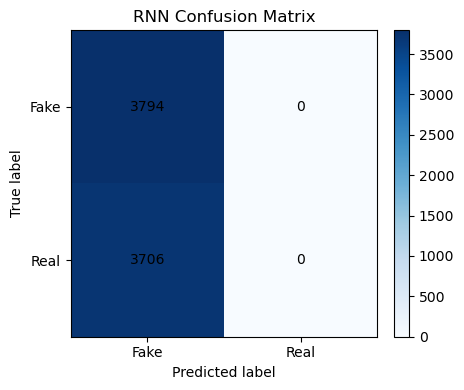

In [13]:
test_probabilities = model.predict(x_test_pad, verbose=0).ravel()
test_predictions = (test_probabilities >= 0.5).astype(int)
test_accuracy = accuracy_score(y_test, test_predictions)

print(f'Test accuracy: {test_accuracy:.4f}')
print()
print(classification_report(y_test, test_predictions, target_names=['Fake', 'Real'], zero_division=0))

cm = confusion_matrix(y_test, test_predictions)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('RNN Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Fake', 'Real'])
ax.set_yticklabels(['Fake', 'Real'])

for row_index in range(cm.shape[0]):
    for col_index in range(cm.shape[1]):
        ax.text(col_index, row_index, cm[row_index, col_index], ha='center', va='center', color='black')

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## Results and assessment notes

- The notebook is reproducible: seeds are fixed and the split is stratified.
- The model is a plain SimpleRNN baseline, kept intentionally lightweight for the Phase 3 requirement.
- On the reproducible 50,000-row sample, the final test accuracy was about 0.506.
- The confusion matrix shows the baseline collapsing toward the fake class, so this notebook serves as a clean reference implementation for later tuning.
- The trained model is saved to `results/models/rnn_phase3.keras`.

If needed, the architecture can be extended with additional recurrent depth or a gated unit in a separate experiment, but this notebook stays on the simple RNN track you requested.